## 1. Project Objectives

The objective of this project is to analyze the key drivers of housing prices in California and develop a machine learning model to estimate property values based on demographic and geographic data.

### Predictive Goal
Build a regression model to predict `median_house_value` using features such as income, housing characteristics, and location.

### Analytical Goal
Quantify the relative impact of economic and geographic factors on housing prices, and assess how these relationships influence model performance.

---

## 2. Stakeholders

### Real Estate Analysts
- Use the model as a **baseline valuation benchmark** to compare property prices across regions  
- Identify areas where pricing deviates from expected patterns for further investigation  

### Lending / Risk Teams
- Support **property value estimation** when assessing loan applications  
- Understand how location and income levels influence valuation risk  

### Data & Analytics Teams
- Leverage the pipeline as a **reusable framework** for building and evaluating regression models  
- Apply similar approaches to other structured prediction problems

In [5]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install geopandas
!pip install geoplot
!pip install scikit-learn
!pip install kagglehub

In [6]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs

# Scikit-learn core
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

# Scikit-learn preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

# Scikit-learn models / utilities
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor



In [7]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("camnugent/california-housing-prices")

# print("Path to dataset files:", path)
# Load the dataset
# df = pd.read_csv("/kaggle/input/california-housing-prices/housing.csv")

In [8]:
#import data
df=pd.read_csv('housing.csv')

# Preliminary Data Check

In [9]:
print("Shape of the Dataset:", df.shape, "\n")
print("First Few Rows of the Dataset:")
print(df.head(10), "\n\n")
print("Dataset Information:")
print(df.info(), "\n\n")
print("Number of Missing Values in Each Column:")
print(df.isna().sum(), "\n\n")
print("Number of Duplicated Rows:\n", df.duplicated().sum(), "\n\n")
print("Description of the Numerical Dataset:\n", df.describe(), "\n\n")
print("Description of Categorical Columns:\n", df.describe(include='object'), "\n\n")
print("Number of Unique Values in Each Column:\n", df.nunique(), "\n\n")

Shape of the Dataset: (20640, 10) 

First Few Rows of the Dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   
7    -122.25     37.84                52.0       3104.0           687.0   
8    -122.26     37.84                42.0       2555.0           665.0   
9    -122.25     37.84                52.0       3549.0           707.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0   

In [10]:
#change the column name to accurately reflect the data it contains
df = df.rename(columns={
    "total_rooms": "total_rooms_block",
    "total_bedrooms": "total_bedrooms_block",
    "population": "population_block",
    "households": "num_households",
    "median_income": "median_income_10k",
    "housing_median_age": "median_house_age"
})

The original dataset uses column names such as total_rooms, population, and households, which can be misleading at first glance, as they may suggest values at an individual property level. However, each row actually represents a census block, not a single house. This means these variables are aggregated counts across a neighborhood.

# Exploratory Data Analysis

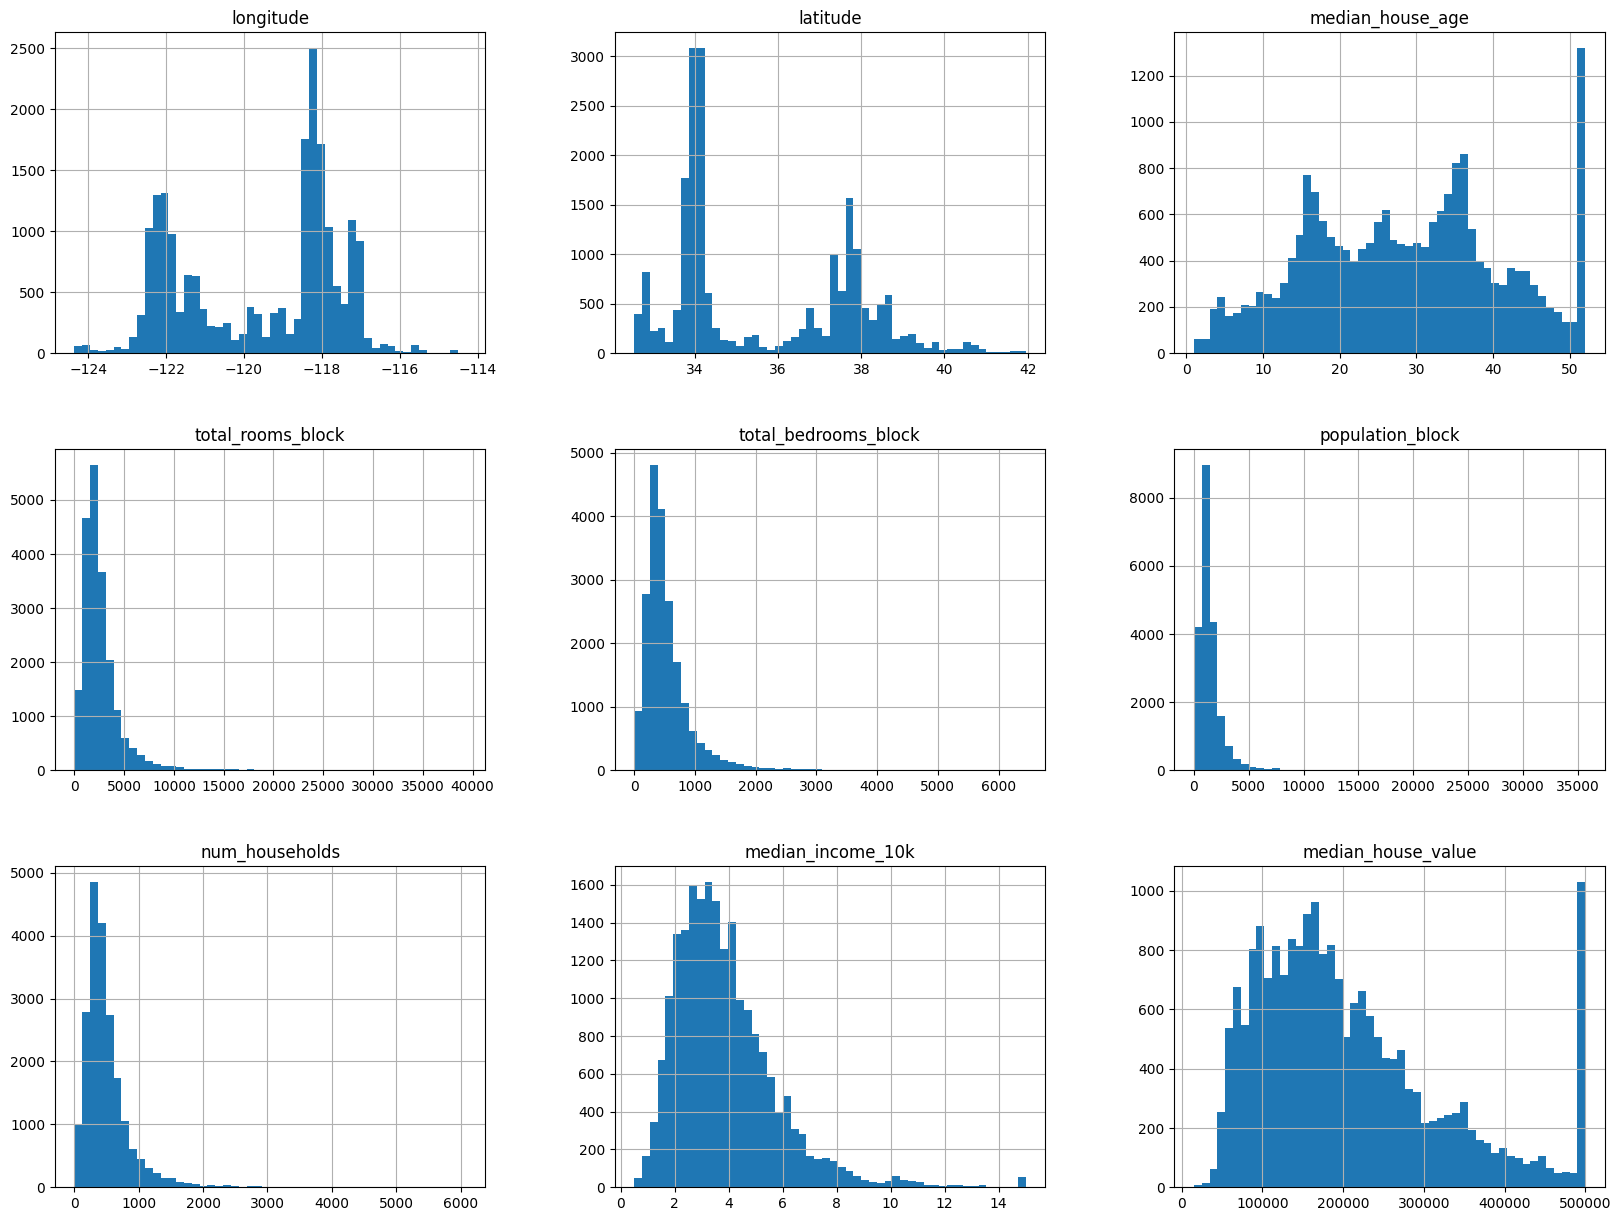

In [11]:
df.hist(bins=50, figsize=(20,15)) #50 bins due to df[age]
plt.show()

The distributions of several features are highly skewed (e.g., population, rooms, households), indicating the presence of extreme values and long tails. Additionally, both median_house_value and median_house_age exhibit capped values, which can introduce bias into the model by artificially limiting the target and feature ranges. To mitigate these issues, capped values in median_house_value will be removed, and appropriate transformations (e.g., log scaling) will be applied to normalize skewed distributions. Furthermore, feature scaling will be performed to ensure that variables with different magnitudes do not disproportionately influence the model.

In [12]:
#remove all values above 500000 in median_house_value column because they are capped values
df=df[df["median_house_value"]<500000]
df.size

196480

In [13]:
#train test stratified split based on median_income_10k column using quantiles cuts
from sklearn.model_selection import train_test_split

# create quantile bins
df["income_cat"] = pd.cut(df["median_income_10k"], bins=[0,1.5,3,4.5,6,np.inf], labels=[1, 2, 3, 4, 5])
# stratified split
train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["income_cat"]
)

Stratified sampling is used on `median_income_10k` because income is the strongest driver of house prices. By splitting based on income categories, both the training and test sets maintain the same income distribution, preventing bias and ensuring more reliable model evaluation.


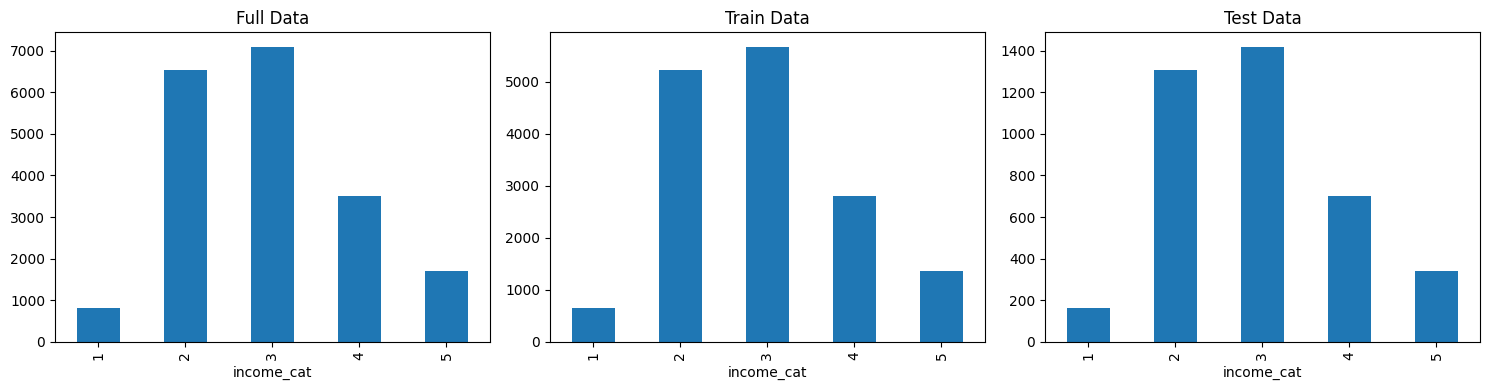

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['income_cat'].value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set_title("Full Data")

train_data['income_cat'].value_counts().sort_index().plot.bar(ax=axes[1])
axes[1].set_title("Train Data")

test_data['income_cat'].value_counts().sort_index().plot.bar(ax=axes[2])
axes[2].set_title("Test Data")

plt.tight_layout()
plt.show()

In [15]:
# drop helper column
for dataset in (train_data, test_data):
    dataset.drop("income_cat", axis=1, inplace=True)

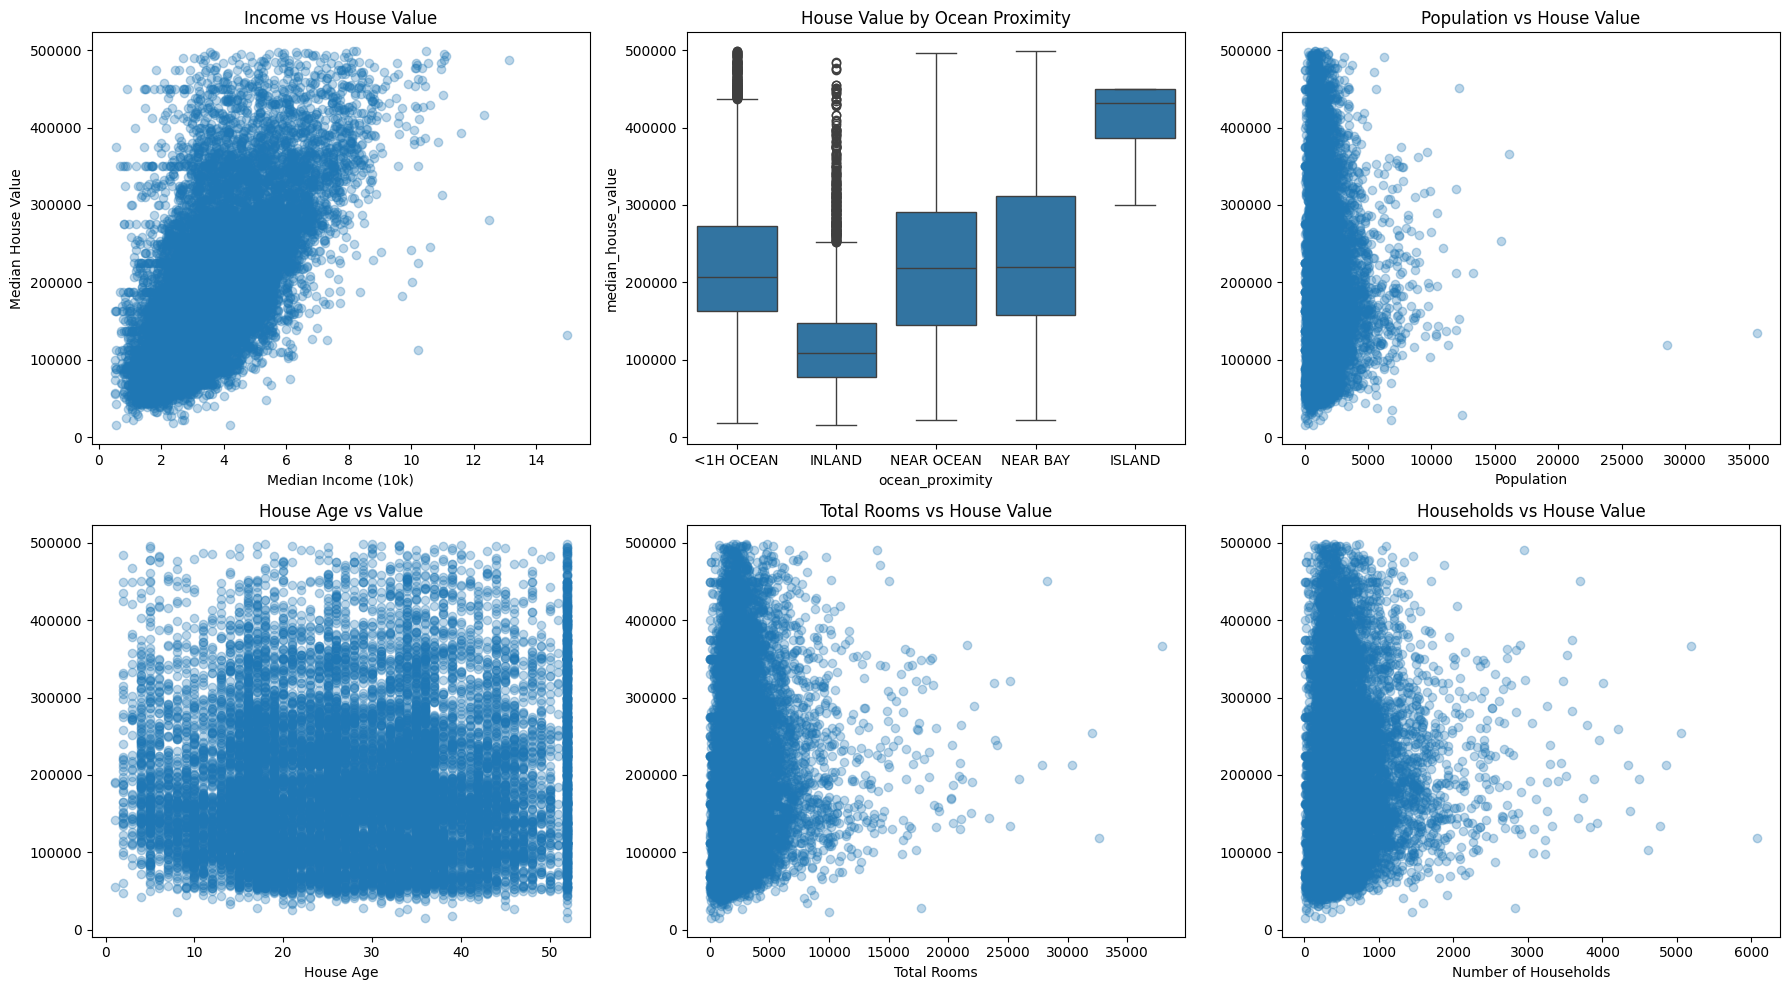

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Income vs Price (with trend)
axes[0, 0].scatter(
    train_data["median_income_10k"],
    train_data["median_house_value"],
    alpha=0.3
)
axes[0, 0].set_xlabel("Median Income (10k)")
axes[0, 0].set_ylabel("Median House Value")
axes[0, 0].set_title("Income vs House Value")

# 2. Ocean Proximity vs Price
sns.boxplot(
    x="ocean_proximity",
    y="median_house_value",
    data=train_data,
    ax=axes[0, 1]
)
axes[0, 1].set_title("House Value by Ocean Proximity")

# 3. Population vs Price
axes[0, 2].scatter(
    train_data["population_block"],
    train_data["median_house_value"],
    alpha=0.3
)
axes[0, 2].set_title("Population vs House Value")
axes[0, 2].set_xlabel("Population")

# 4. House Age vs Price
axes[1, 0].scatter(
    train_data["median_house_age"],
    train_data["median_house_value"],
    alpha=0.3
)
axes[1, 0].set_title("House Age vs Value")
axes[1, 0].set_xlabel("House Age")

# 5. Rooms per Block vs Price
axes[1, 1].scatter(
    train_data["total_rooms_block"],
    train_data["median_house_value"],
    alpha=0.3
)
axes[1, 1].set_title("Total Rooms vs House Value")
axes[1, 1].set_xlabel("Total Rooms")

# 6. Households vs Price
axes[1, 2].scatter(
    train_data["num_households"],
    train_data["median_house_value"],
    alpha=0.3
)
axes[1, 2].set_title("Households vs House Value")
axes[1, 2].set_xlabel("Number of Households")

plt.tight_layout()
plt.show()

Housing prices in California are primarily driven by **median income and geographic location**. The analysis shows a strong positive linear relationship between income and house value, indicating that areas with higher purchasing power consistently have higher property prices. Additionally, proximity to the ocean introduces a clear price premium, with coastal regions (such as those near the bay or ocean) significantly outperforming inland areas. In contrast, variables like population, house age, total rooms, and number of households exhibit weak or noisy individual relationships with price, suggesting they are not strong standalone predictors. However, these features may still contribute through nonlinear interactions captured by machine learning models. Overall, the results highlight that **economic capacity and location desirability** are the dominant factors influencing housing values, which is critical for investors, urban planners, and lenders when making data-driven decisions.


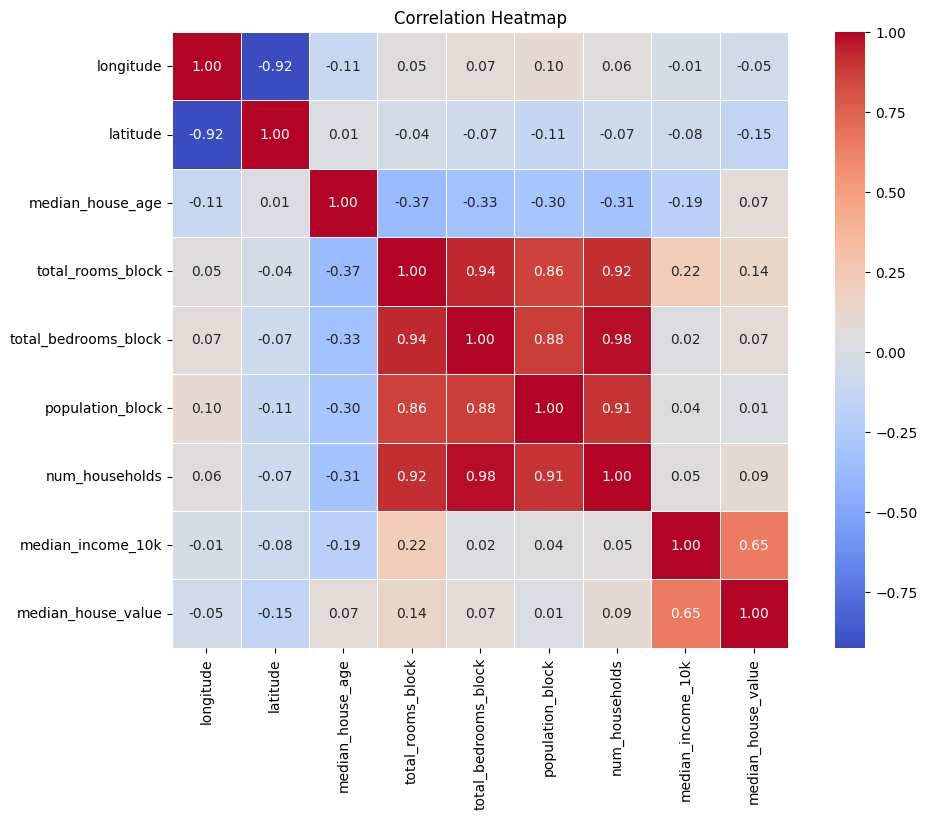

In [17]:
# Plot heatmap
corr_matrix = train_data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [18]:
#sort correlation matrix by highest to lowest correlation by absolute value
corr_matrix_sorted = corr_matrix["median_house_value"].abs().sort_values(ascending=False)
print(corr_matrix_sorted)

median_house_value      1.000000
median_income_10k       0.649208
latitude                0.148557
total_rooms_block       0.142174
num_households          0.092148
total_bedrooms_block    0.072071
median_house_age        0.068357
longitude               0.046475
population_block        0.010607
Name: median_house_value, dtype: float64


`median_income_10k` shows the strongest correlation (~0.65) with house value, making it the main driver. All other features have much weaker linear relationships, meaning their impact is smaller or likely non-linear.


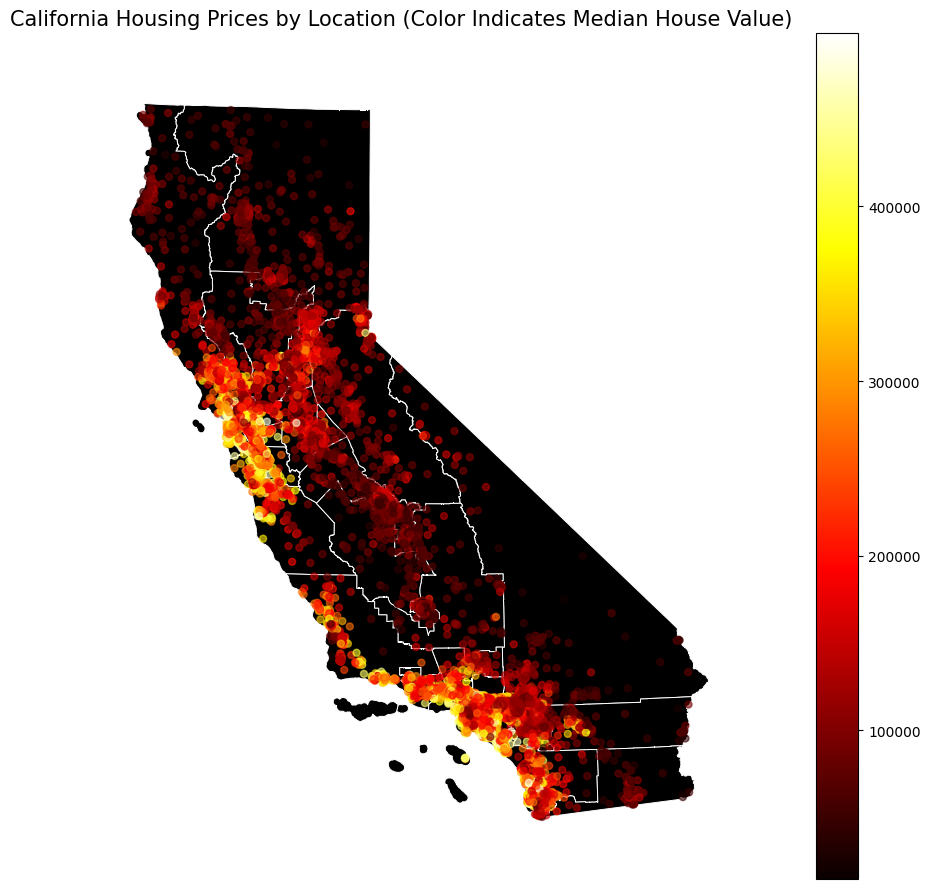

In [19]:
cali = gpd.read_file(gplt.datasets.get_path('california_congressional_districts'))

# Load your training data and convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    train_data,
    geometry=gpd.points_from_xy(train_data.longitude, train_data.latitude),
    crs="EPSG:4326"
)

proj = gcrs.AlbersEqualArea(central_latitude=37.16611, central_longitude=-119.44944)

# Plot
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': proj})
gplt.polyplot(cali, projection=proj, ax=ax, facecolor='black', edgecolor='white', linewidth=0.7)


gplt.pointplot(
    gdf,
    ax=ax,
    projection=proj,
    hue='median_house_value',
    cmap='hot',
    legend=True,
    alpha=0.6
)

# Title and layout
ax.set_title("California Housing Prices by Location (Color Indicates Median House Value)", fontsize=15)
plt.tight_layout()

Since housing prices clearly vary by location, especially with higher values near the coast and major cities, we use latitude and longitude to create more meaningful geographic features. Instead of using raw coordinates, we group locations into clusters and measure how similar each point is to these clusters. This helps the model better understand spatial patterns like proximity to high-value areas.


# Data Preprocessing Pipeline

In [20]:

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    """
    Transforms data into similarities to cluster centers using the RBF kernel.
    """

    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, input_features=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]


In [21]:
# Feature engineering functions
def compute_ratio(X):
    """
    Computes the ratio of the first column to the second column.
    """
    return X[:, [0]] / X[:, [1]]


def ratio_feature_names(transformer, feature_names_in):
    return ["ratio"]



In [22]:
# Pipelines for different feature types
def make_ratio_pipeline():
    """
    Pipeline for computing ratios between two features with imputation and scaling.
    """
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(compute_ratio, feature_names_out=ratio_feature_names),
        StandardScaler()
    )


def make_log_pipeline():
    """
    Pipeline for log-transforming features with imputation and scaling.
    """
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(np.log1p, feature_names_out="one-to-one"),  # log1p for better stability
        StandardScaler()
    )


def make_categorical_pipeline():
    """
    Pipeline for categorical features: imputation and one-hot encoding.
    """
    return make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore")
    )


def make_default_numeric_pipeline():
    """
    Default numeric preprocessing pipeline with imputation and scaling.
    """
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler()
    )

In [23]:
cluster_similarity_transformer = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

In [24]:
# Index(['longitude', 'latitude', 'median_house_age', 'total_rooms_block',
#        'total_bedrooms_block', 'population_block', 'num_households',
#        'median_income_10k', 'median_house_value', 'ocean_proximity',
#        'income_cat'],
#       dtype='object')

# Full preprocessing pipeline
full_preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ("bedrooms_ratio", make_ratio_pipeline(), ["total_bedrooms_block", "total_rooms_block"]),
        ("rooms_per_house", make_ratio_pipeline(), ["total_rooms_block", "num_households"]),
        ("people_per_house", make_ratio_pipeline(), ["population_block", "num_households"]),
        ("log_features", make_log_pipeline(), ["total_bedrooms_block", "total_rooms_block", "population_block", "num_households","median_income_10k"]),
        ("geo_similarity", cluster_similarity_transformer, ["latitude", "longitude"]),
        ("categorical", make_categorical_pipeline(), ["ocean_proximity"])
    ],
    remainder=make_default_numeric_pipeline()
)

# Machine Learning Modelling

In [25]:
#Features and target separation

train_features = train_data.drop("median_house_value", axis=1)
train_target = train_data["median_house_value"].copy()
test_features = test_data.drop("median_house_value", axis=1)
test_target = test_data["median_house_value"].copy()


In [26]:

# Compare many regression models using TRAIN data only

def compare_regression_models(preprocessor, models, X_train, y_train, cv=10):
    """
    Compare multiple regression models using cross-validation on training data only.

    Parameters
    ----------
    preprocessor : transformer/pipeline
        Your preprocessing pipeline.
    models : dict
        Dictionary like:
        {
            "Linear Regression": LinearRegression(),
            "Random Forest": RandomForestRegressor(...)
        }
    X_train : pd.DataFrame
    y_train : pd.Series or np.array
    cv : int
        Number of CV folds.

    Returns
    -------
    results_df : pd.DataFrame
        Sorted comparison table.
    best_model_name : str
        Name of model with lowest mean CV RMSE.
    best_model : estimator
        Best estimator object (not yet fitted).
    """ 
    results = []

    for model_name, model in models.items():
        pipeline = make_pipeline(preprocessor, model)

        cv_scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            scoring="neg_mean_squared_error",
            cv=cv,
            n_jobs=-1
        )

        cv_rmse = np.sqrt(-cv_scores)

        results.append({
            "model": model_name,
            "cv_rmse_mean": cv_rmse.mean(),
            "cv_rmse_std": cv_rmse.std(),
            "cv_rmse_scores": cv_rmse
        })

        print(f"{model_name}")
        print("CV RMSE scores:", np.round(cv_rmse, 4))
        print("Mean CV RMSE:", round(cv_rmse.mean(), 4))
        print("Std CV RMSE:", round(cv_rmse.std(), 4))
        print("-" * 50)

    results_df = pd.DataFrame(results).sort_values("cv_rmse_mean", ascending=True).reset_index(drop=True)

    best_model_name = results_df.loc[0, "model"]
    best_model = models[best_model_name]

    print("\nModel comparison summary:")
    print(results_df[["model", "cv_rmse_mean", "cv_rmse_std"]])

    print(f"\nBest model based on CV RMSE: {best_model_name}")

    return results_df, best_model_name, best_model



# Final evaluation on test set AFTER model selection

def final_evaluate_regression_model(
    preprocessor,
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    plot_top_n=15,
    n_repeats=10,
    random_state=42
):
    """
    Fit the chosen model on full training data, evaluate on test data,
    and compute permutation importance on test data.
    """

    pipeline = make_pipeline(preprocessor, model)

    # Fit on full training data
    pipeline.fit(X_train, y_train)

    # Predict on test set
    test_predictions = pipeline.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    print(f"\nFinal chosen model: {model_name}")
    print(f"Final Test RMSE: {test_rmse:.4f}")

    # Permutation importance on original columns
    perm_result = permutation_importance(
        pipeline,
        X_test,
        y_test,
        scoring="neg_mean_squared_error",
        n_repeats=n_repeats,
        random_state=random_state
    )

    feature_names = X_test.columns.tolist()

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    print("\nPermutation Feature Importance:")
    print(importance_df)

    # Plot top features
    top_features = importance_df.head(plot_top_n).sort_values("importance_mean")

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["feature"], top_features["importance_mean"])
    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {plot_top_n} Feature Importances - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline,
        "test_rmse": test_rmse,
        "test_predictions": test_predictions,
        "feature_importance": importance_df
    }

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Model Evaluation

In [28]:
#compare models using training data only
comparison_df, best_model_name, best_model = compare_regression_models(
    preprocessor=full_preprocessing_pipeline,
    models=models,
    X_train=train_features,
    y_train=train_target,
    cv=10
)

Linear Regression
CV RMSE scores: [65047.4577 60964.4194 60498.5102 62363.5349 54972.5603 60265.4504
 58662.0556 58921.3304 58502.7511 58541.8021]
Mean CV RMSE: 59873.9872
Std CV RMSE: 2544.6077
--------------------------------------------------
Ridge Regression
CV RMSE scores: [64793.5126 60938.6658 60499.7086 62358.0803 55005.9814 60257.7688
 58669.9649 58920.2817 58524.3177 58540.0118]
Mean CV RMSE: 59850.8294
Std CV RMSE: 2483.893
--------------------------------------------------
Decision Tree
CV RMSE scores: [60625.5357 60685.7593 59881.3225 60572.7425 59851.744  62200.8741
 58148.1162 59422.3831 58688.4801 59766.8636]
Mean CV RMSE: 59984.3821
Std CV RMSE: 1077.2473
--------------------------------------------------
Random Forest
CV RMSE scores: [42055.8032 43812.9306 42768.7968 46128.3134 40974.8513 43956.5261
 41721.8883 40720.2686 43370.3971 43365.815 ]
Mean CV RMSE: 42887.5591
Std CV RMSE: 1529.1718
--------------------------------------------------
Gradient Boosting
CV RMSE 


Final chosen model: Random Forest
Final Test RMSE: 40544.8739

Permutation Feature Importance:
                feature  importance_mean  importance_std
0     median_income_10k     4.853939e+09    1.063517e+08
1       ocean_proximity     2.127518e+09    7.241240e+07
2             longitude     2.110921e+09    5.463597e+07
3      population_block     2.001517e+09    8.448384e+07
4              latitude     1.791617e+09    4.408577e+07
5        num_households     1.632590e+09    2.674990e+07
6     total_rooms_block     9.865444e+08    2.816546e+07
7      median_house_age     3.596389e+08    3.010033e+07
8  total_bedrooms_block     3.350409e+08    1.259837e+07


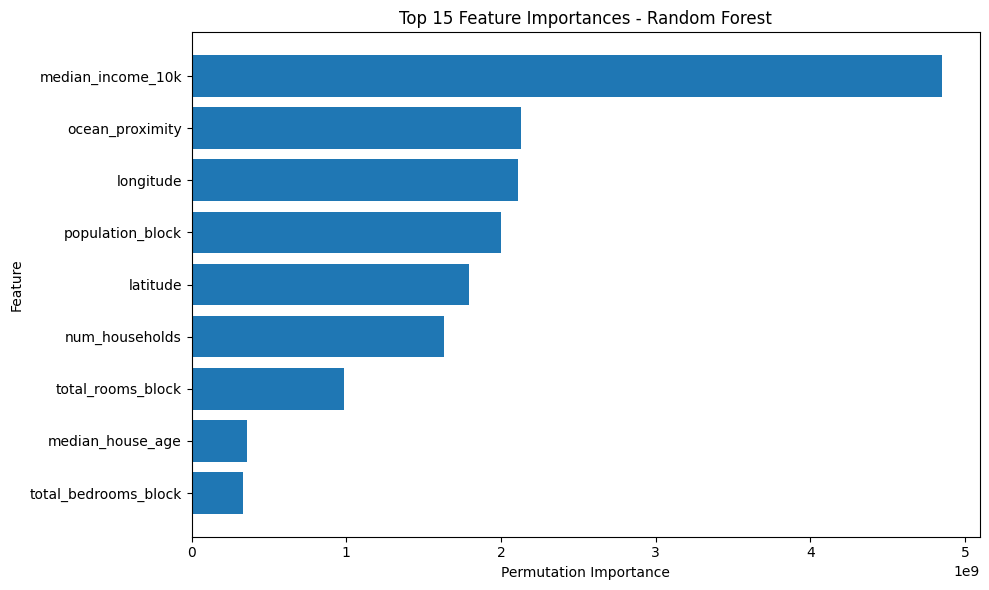

In [29]:
# final evaluation of best model on test set
final_results = final_evaluate_regression_model(
    preprocessor=full_preprocessing_pipeline,
    model=best_model,
    model_name=best_model_name,
    X_train=train_features,
    y_train=train_target,
    X_test=test_features,
    y_test=test_target,
    plot_top_n=15
)

Income-related signals dominate the model’s predictions, with geographic features also playing a major role. This indicates that both economic capacity and location are key determinants of housing prices, while structural housing attributes contribute comparatively less to predictive performance.

# Error Analysis

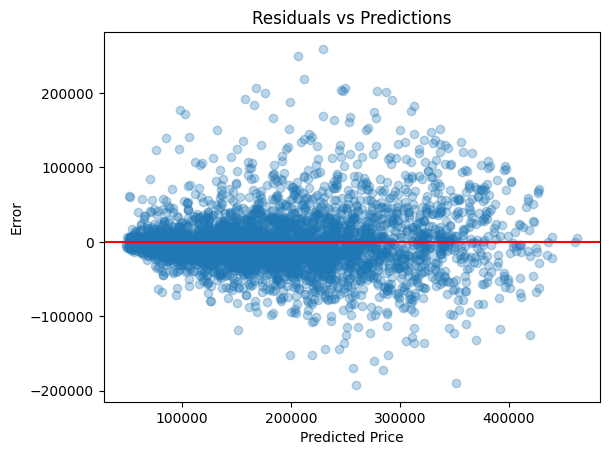

In [30]:
errors = test_target - final_results["test_predictions"]

plt.scatter(final_results["test_predictions"], errors, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Error")
plt.title("Residuals vs Predictions")
plt.show()

The residuals are generally centered around zero, indicating that the model is not strongly biased and predictions are, on average, accurate. However, the spread of errors is largest around mid-range predicted prices, suggesting the model is less precise for moderately priced houses. This indicates that the model performs more consistently at the lower and higher ends of the price range, but struggles more with mid-priced properties.


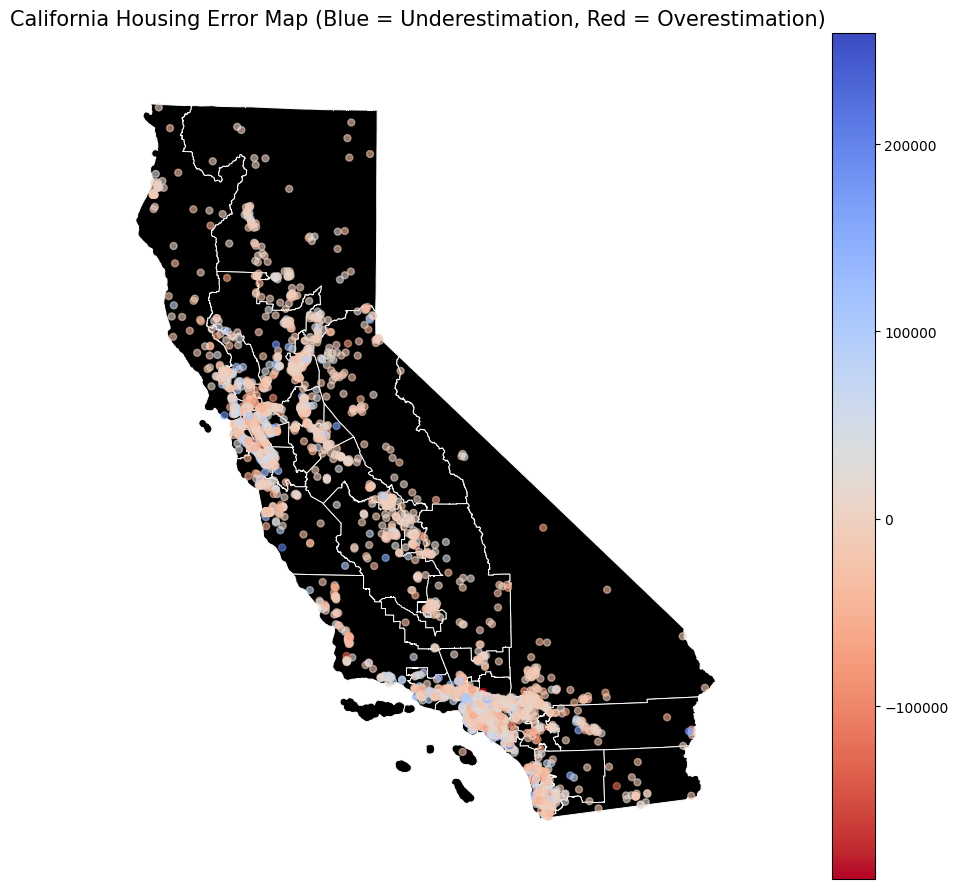

In [31]:
# Load California map
cali = gpd.read_file(gplt.datasets.get_path('california_congressional_districts'))

# Prepare error dataframe
error_df = test_data.copy()
error_df["prediction"] = final_results["test_predictions"]
error_df["error"] = error_df["median_house_value"] - error_df["prediction"]

# Convert to GeoDataFrame
gdf_error = gpd.GeoDataFrame(
    error_df,
    geometry=gpd.points_from_xy(error_df.longitude, error_df.latitude),
    crs="EPSG:4326"
)

# Projection
proj = gcrs.AlbersEqualArea(
    central_latitude=37.16611,
    central_longitude=-119.44944
)

# Plot
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': proj})

# Background map
gplt.polyplot(
    cali,
    projection=proj,
    ax=ax,
    facecolor='black',
    edgecolor='white',
    linewidth=0.7
)

# Error points
gplt.pointplot(
    gdf_error,
    ax=ax,
    projection=proj,
    hue="error",
    cmap="coolwarm_r",   # blue = underestimation, red = overestimation
    legend=True,
    alpha=0.6
)

# Title
ax.set_title(
    "California Housing Error Map (Blue = Underestimation, Red = Overestimation)",
    fontsize=15
)

plt.tight_layout()
plt.show()

The geographic error distribution does not reveal a strong regional pattern, suggesting that location-based features have already been effectively captured by the model. While no clear systematic geographic bias is observed, individual prediction errors still vary across regions.

By comparing predicted prices with actual values, properties with large positive errors (actual > predicted) may indicate undervaluation, while negative errors suggest overvaluation. This provides a practical signal for investment opportunities.

Overestimated: 2247 (57.18%)
Underestimated: 1683 (42.82%)
Exact: 0 (0.00%)


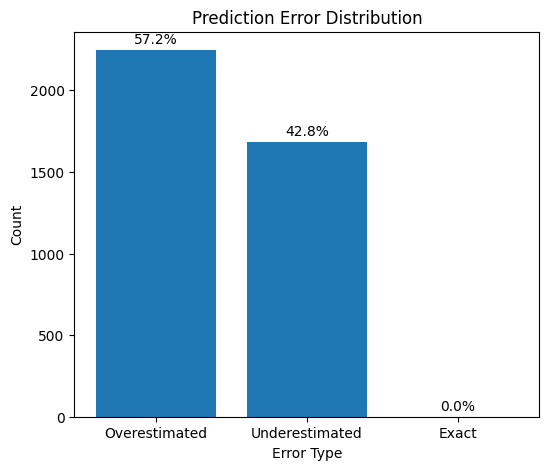

In [32]:
import matplotlib.pyplot as plt

# Define error
error = test_target - final_results["test_predictions"]

# Classify
overestimated = (error < 0).sum()     # predicted > actual
underestimated = (error > 0).sum()    # predicted < actual
exact = (error == 0).sum()

# Total
total = len(error)

# Percentages
over_pct = overestimated / total * 100
under_pct = underestimated / total * 100
exact_pct = exact / total * 100

# Print (useful for markdown insight)
print(f"Overestimated: {overestimated} ({over_pct:.2f}%)")
print(f"Underestimated: {underestimated} ({under_pct:.2f}%)")
print(f"Exact: {exact} ({exact_pct:.2f}%)")

# Plot
labels = ["Overestimated", "Underestimated", "Exact"]
counts = [overestimated, underestimated, exact]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, counts)

# Add percentage labels on top
for i, v in enumerate(counts):
    pct = v / total * 100
    plt.text(i, v + total*0.01, f"{pct:.1f}%", ha='center')

plt.title("Prediction Error Distribution")
plt.ylabel("Count")
plt.xlabel("Error Type")

plt.show()

The model has slightly more overestimation error

## Overall Insight

Housing prices are primarily driven by **income levels and geographic location**, rather than purely structural housing characteristics. This indicates that real estate value is largely determined by **economic strength and spatial factors**, while variables such as population, housing age, and number of rooms play a more limited standalone role.

---

## Business Interpretation

### Real Estate Analysts

The model provides a **baseline valuation benchmark** for comparing predicted and actual property prices across regions.

- Higher-income areas consistently show higher property values, suggesting income can be used as a strong proxy for demand and purchasing power. This is particularly useful for investors targeting high-growth regions.
- Geographic clustering suggests that nearby regions exhibit similar pricing patterns, indicating that localized factors (e.g., neighborhood effects and accessibility) play an important role in valuation. 

Rather than directly identifying “undervalued” properties, differences between predicted and actual prices should be used to **flag areas for further investigation**, as they may reflect missing factors or localized market conditions.

---

### Lending / Risk Teams

The model supports **property value estimation** and highlights areas of varying prediction reliability.

- Prediction errors are higher in **mid-priced properties**, indicating greater uncertainty  
- Lower and higher-priced homes tend to be estimated more consistently  

This suggests that model outputs should be used as **approximate benchmarks**, with additional caution in segments or regions where prediction uncertainty is higher.

---

### Data & Analytics Teams

The project demonstrates a **modular machine learning pipeline** for structured regression problems.

- Combines preprocessing, feature engineering, and modeling into a single workflow  
- Ensures consistent transformations between training and prediction  
- Can be adapted and reused for similar tabular prediction tasks  

---

## Model Limitations

- The dataset includes **capped house values**, which may distort high-end price behavior  
- Important real-world factors are not included (e.g., economic conditions, local amenities)  
- Feature importance reflects **model dependence**, not causality  
- Prediction errors vary across price segments, indicating uneven performance
- Hyperparameter tuning was not extensively performed, meaning model performance could likely be further improved with more time and optimization
- Results are based on exploratory analysis and modeling assumptions, and may be sensitive to feature engineering choices or preprocessing decisions

---

## Conclusion

The project identifies **income and geographic location as the primary drivers of housing prices**, with other variables contributing in a more limited or nonlinear way.

The model serves as a **reliable baseline for price estimation and pattern analysis**, supporting comparison across regions and highlighting areas where further investigation is needed. It should be used as a decision-support tool rather than a standalone source of truth.